<a href="https://colab.research.google.com/github/kibwale/nipe_macho/blob/main/notebooks/potholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI project

# Potholes Detection

**Updated**: June 2026
**Framework**: Fynesse (Access, Assess, Address)  
**Environment**: colab notebook

This notebook demonstrates the complete Fynesse data analysis pipeline using modern Python development practices.

### **Abstract**

Road potholes pose significant challenges to transportation infrastructure, contributing to vehicle damage, increased maintenance costs, traffic disruptions, and road safety hazards. Traditional road inspection methods rely heavily on manual surveys, which are often time-consuming, labor-intensive, and inefficient for large road networks. This project presents an AI-based pothole detection system utilizing the YOLOv8 object detection framework to automatically identify potholes from road images collected on Kenyan roads.

The system is trained on a custom annotated dataset and evaluated using standard object detection metrics, including precision, recall, and mean Average Precision (mAP). In addition to pothole detection, the project incorporates severity assessment based on pothole dimensions extracted from detection results. Geographical coordinates embedded within image metadata are also utilized to map pothole locations, enabling the creation of an interactive road condition monitoring platform.

The proposed solution demonstrates the potential of combining deep learning and geospatial technologies to support efficient road maintenance planning, improve road safety, and provide a scalable approach to infrastructure monitoring in developing regions.


---
## 1. Setting up the Environment
#### Verify GPU Access
let's make sure that we have access to a GPU before we start training the model. Training on a GPU is exponentially faster than on a CPU.

We can use the `nvidia-smi` command to verify our hardware allocation. This command displays the current GPU model, memory usage, and CUDA version.


In [1]:
!nvidia-smi

Mon Jun 29 13:06:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----



Before beginning ouranalysis , we must configure the Google Colab environment.

YOLOv8 requires specific versions of Numpy and Pandas to prevent dependency conflicts with Colab's default pre-installed libraries. The following cell installs the required packages and safely restarts the Colab runtime to apply them.

In [2]:
!pip install --quiet "numpy==1.26.4" "pandas==2.2.2" "ultralytics==8.2.103" "roboflow" 2>/dev/null
# Restart the Colab runtime automatically so the new Numpy takes effect

#import os
#os.kill(os.getpid(), 9)

#!pip uninstall -y numpy pandas
#!pip install numpy==1.26.4
#!pip install pandas==2.2.2
#!pip install ultralytics==8.2.103 -q

#!pip install roboflow
# Import common data science libraries
#import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
from google.colab import userdata
from roboflow import Roboflow
import os
import glob
import random


# Import the Fynesse framework
#import fynesse
#from fynesse import access, assess, address

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 70.3 MB/s eta 0:00:00


In [3]:

# @title fynesse(not currently used)
#### Cloning the Project Repository To utilize our custom Python modules and keep our project organized, we need to pull the latest version of our project repository into the Colab environment.The following cell performs a fresh clone by first removing any outdated versions of the folder, downloading the latest code from GitHub, and appending the repository to our system path so we can easily import our custom scripts.
# Remove existing repository folder to ensure a clean clone and setup
#import shutil
#shutil.rmtree("/content/nipe_macho", ignore_errors=True)
# Clone the latest version of the repository from GitHub

#!git clone https://github.com/silprosa/nipe_macho.git
#import os, subprocess, importlib, sys
#sys.path.append("/content/nipe_macho")

## 2. Initializing the YOLOv8 Base Model
Before we train the AI on our custom pothole dataset, we need to initialize a foundational model.

Instead of training a neural network completely from scratch—which requires massive amounts of time and data—we use **Transfer Learning**. In this cell, we load `yolov8n.pt` (the lightweight "Nano" version of YOLOv8), which has already been pre-trained on the massive COCO dataset. Because it already recognizes basic edges, shapes, and generic objects, it will learn to identify potholes much faster.


The Nano architecture was chosen specifically to balance high accuracy with fast, real-time inference speeds suitable for edge devices.

In [4]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 89.3MB/s]


A deeper dive into the YOLOv8 architecture and its capabilities can be found in the official [Ultralytics documentation](https://docs.ultralytics.com/models/yolov8#yolov8-usage-examples).

In [5]:
model.info()

YOLOv8n summary: 225 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(225, 3157200, 0, 8.8575488)

---

## 3. Data Acquisition


Instead of hardcoding our private Roboflow API key directly into the notebook—which poses a severe security risk if the notebook is ever shared or committed to GitHub—we utilize Google Colab's built-in **Secrets** manager.

*To run this cell successfully, click the 🔑 Secrets icon on the left sidebar of Colab, add a new secret named `roboflow_api`, and paste your Roboflow API key as the value. Ensure the "Notebook access" toggle is turned on.*

In [6]:
# safely retrieve our secret value
api_key = userdata.get('roboflow_api')
rf = Roboflow(api_key=api_key)

### Fetching the Chepalungu Dataset
Using our authenticated Roboflow connection, we define our specific target directory. We navigate to the `nipemacho` workspace and select the `chepalungu` project.

The following cell downloads version 1 of our annotated pothole dataset into Colab, specifying 'yolov8' as the export format.
This formats the dataset and annotations into normalized text files compatible with YOLO architecture.

In [7]:
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolov8:: 100%|██████████| 527/527 [00:00<00:00, 5131.30it/s]


In [8]:
print(dataset.location) # Prints the local directory where the dataset is downloaded

/content/chepalungu-1


## Phase 2: Assess (Dataset Verification)

During the annotation and export phase (via Roboflow), our dataset was automatically divided into three distinct splits: **train**, **valid** (validation), and **test**.

YOLO formats its annotations as `.txt` files containing normalized coordinates alongside these images. Before we begin training, we must perform a quick sanity check to ensure these folders were downloaded correctly and contain the expected number of images.

*(Note: We don't need to manually verify the bounding box coordinates or background images here, as the YOLOv8 training algorithm automatically performs a deep scan and summarizes dataset health before the first epoch begins).*

In [10]:
import os

# Do a simple count of the files in the training folder
train_dir = f"{dataset.location}/train/images"
image_count = len(os.listdir(train_dir))

print(f"Found {image_count} images in the training folder.")

Found 183 images in the training folder.


## 4. Model Training

With our dataset verified and our hardware configured, we initiate the training sequence.

We are training the **YOLOv8s (Small)** architecture for 25 epochs. We have explicitly set the image size (`imgsz`) to 800 pixels (larger than the default 640) to preserve the resolution of smaller, distant road defects. Additionally, setting `plots=True` ensures the system automatically generates evaluation metrics, loss curves, and confusion matrices upon completion.

In [11]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

100% 21.5M/21.5M [00:00<00:00, 209MB/s]
New https://pypi.org/project/ultralytics/8.4.82 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/chepalungu-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, reti

## 5. Model Evaluation

Once training is complete, we must evaluate the model's performance to ensure it has converged correctly and is not overfitting.


#### Locating the Model Weights and Results
When YOLOv8 completes a training run, it automatically generates a directory to save all outputs, including the finalized model weights (`best.pt`), evaluation charts, and validation predictions.

By default, Ultralytics structures this path as `runs/[task]/[mode]`. Since we performed object **detection** in **training** mode, our initial results are saved to `runs/detect/train`.

*(Note: If you run the training cell multiple times, YOLO will automatically create new folders sequentially, such as `train2`, `train3`, etc. to prevent overwriting your previous work. Ensure this path points to your most recent successful run).*

In [12]:
# Define the results directory
results_dir = 'runs/detect/train'

YOLOv8 automatically generates comprehensive evaluation metrics during the training process. In the cell below, we extract and visualize:
1. **Training Metrics (`results.png`):** A graphical overview of the Loss curves, Precision, Recall, and mAP across all 25 epochs.


--- Training Metrics ---


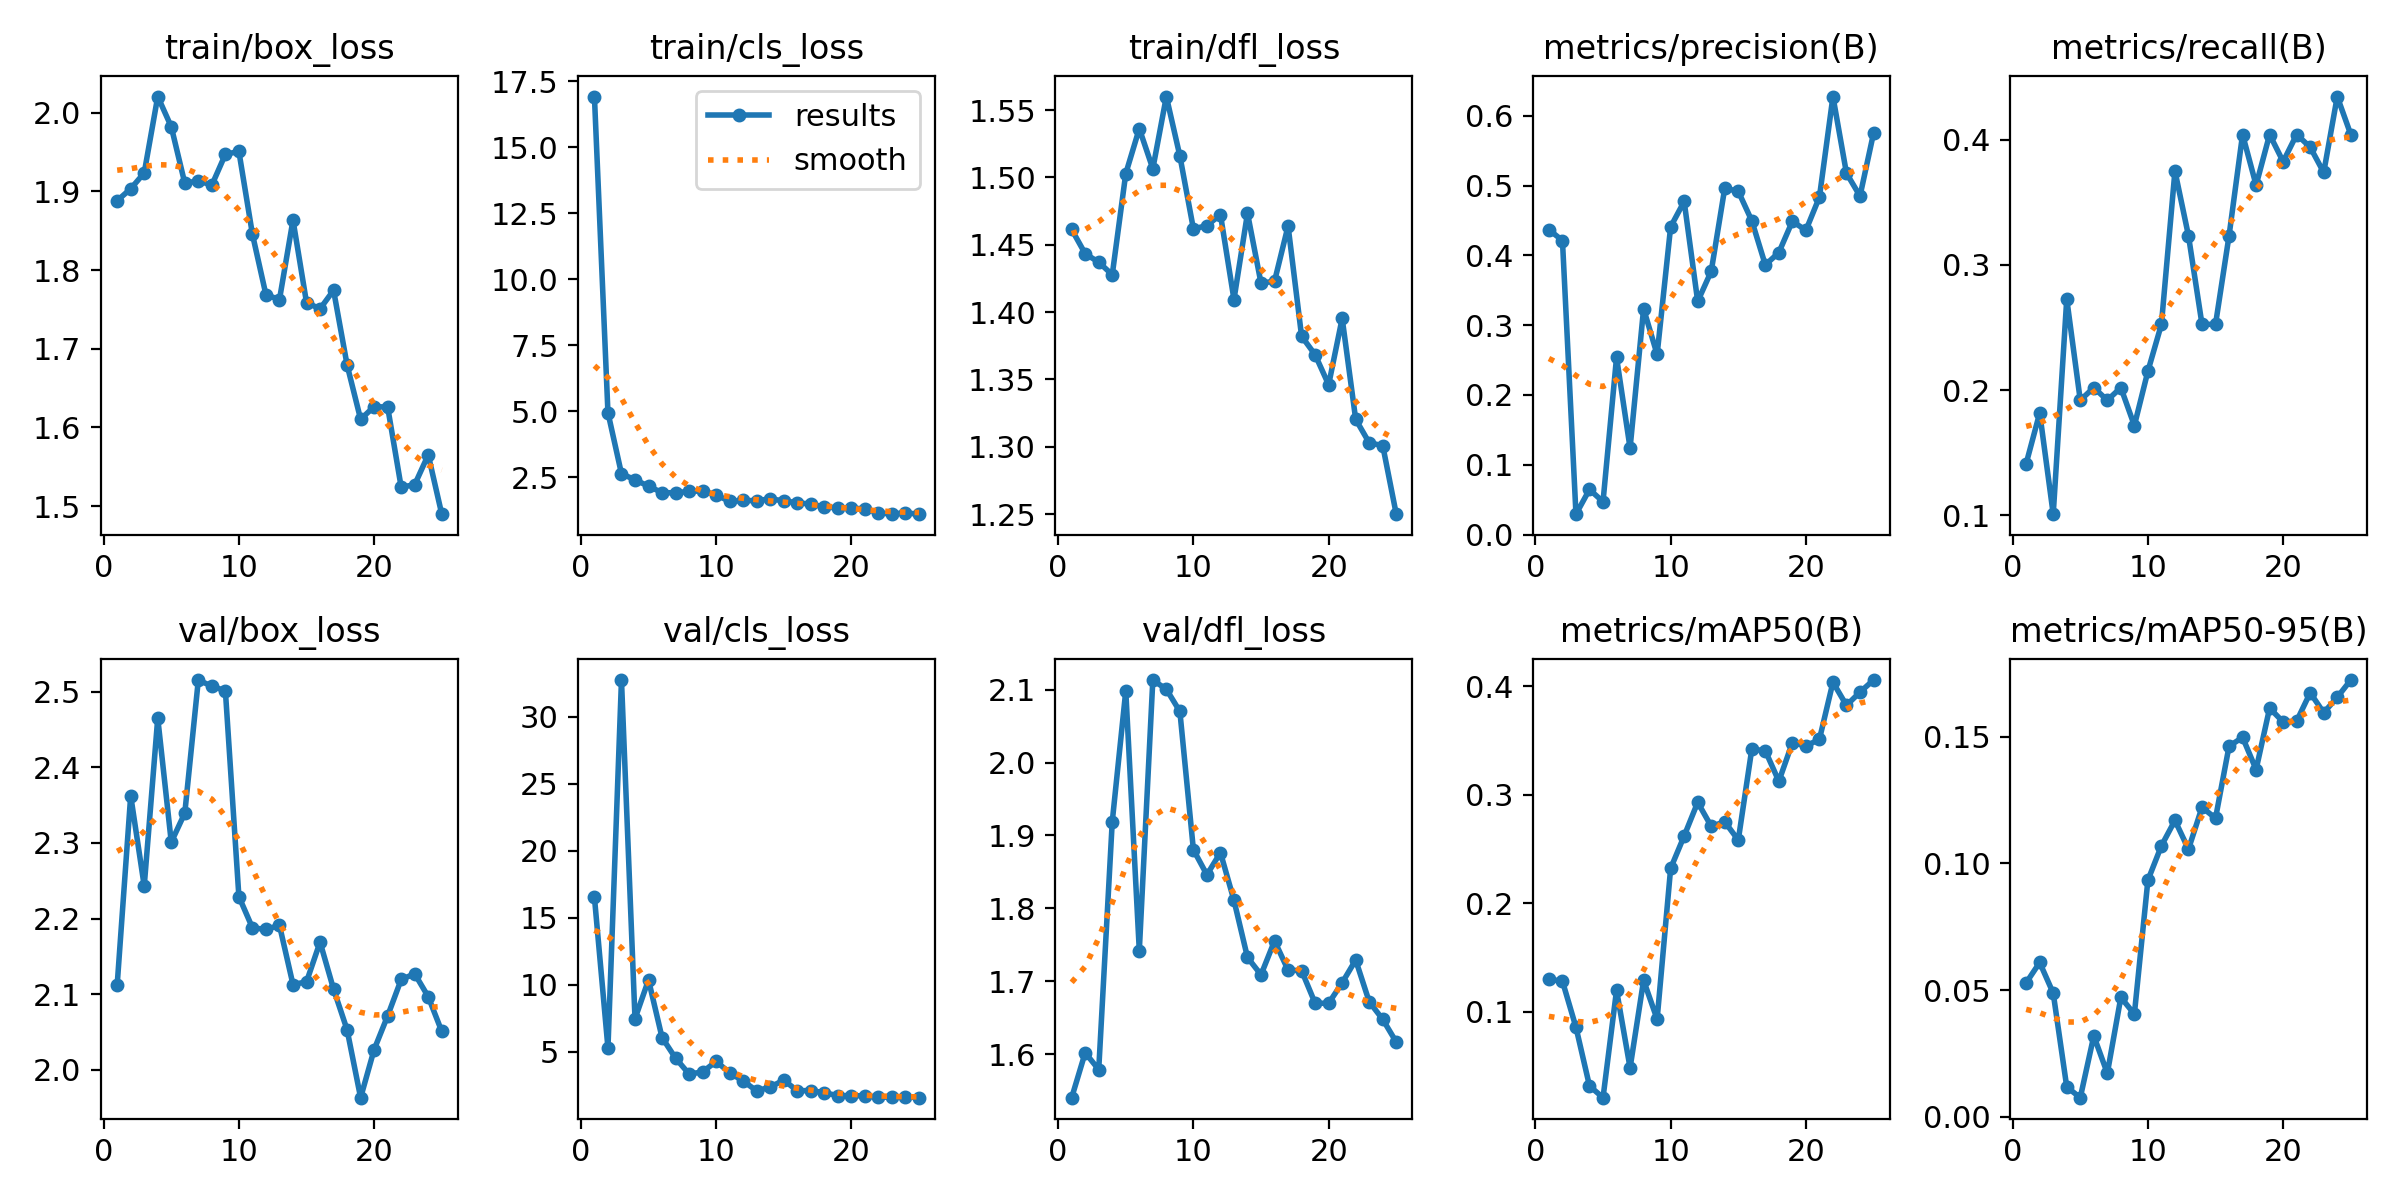

In [13]:
# 1. Display results plot (loss and metrics over epochs)
results_plot = f'{results_dir}/results.png'

if os.path.exists(results_plot):
    print("--- Training Metrics ---")
    display(Image(filename=results_plot, width=800))
else:
    print("results.png not found in the specified directory.")

3. **Validation Batches:** Visual overlays of the model's predictions on the unseen validation dataset to physically confirm bounding box accuracy

--- Validation Predictions ---


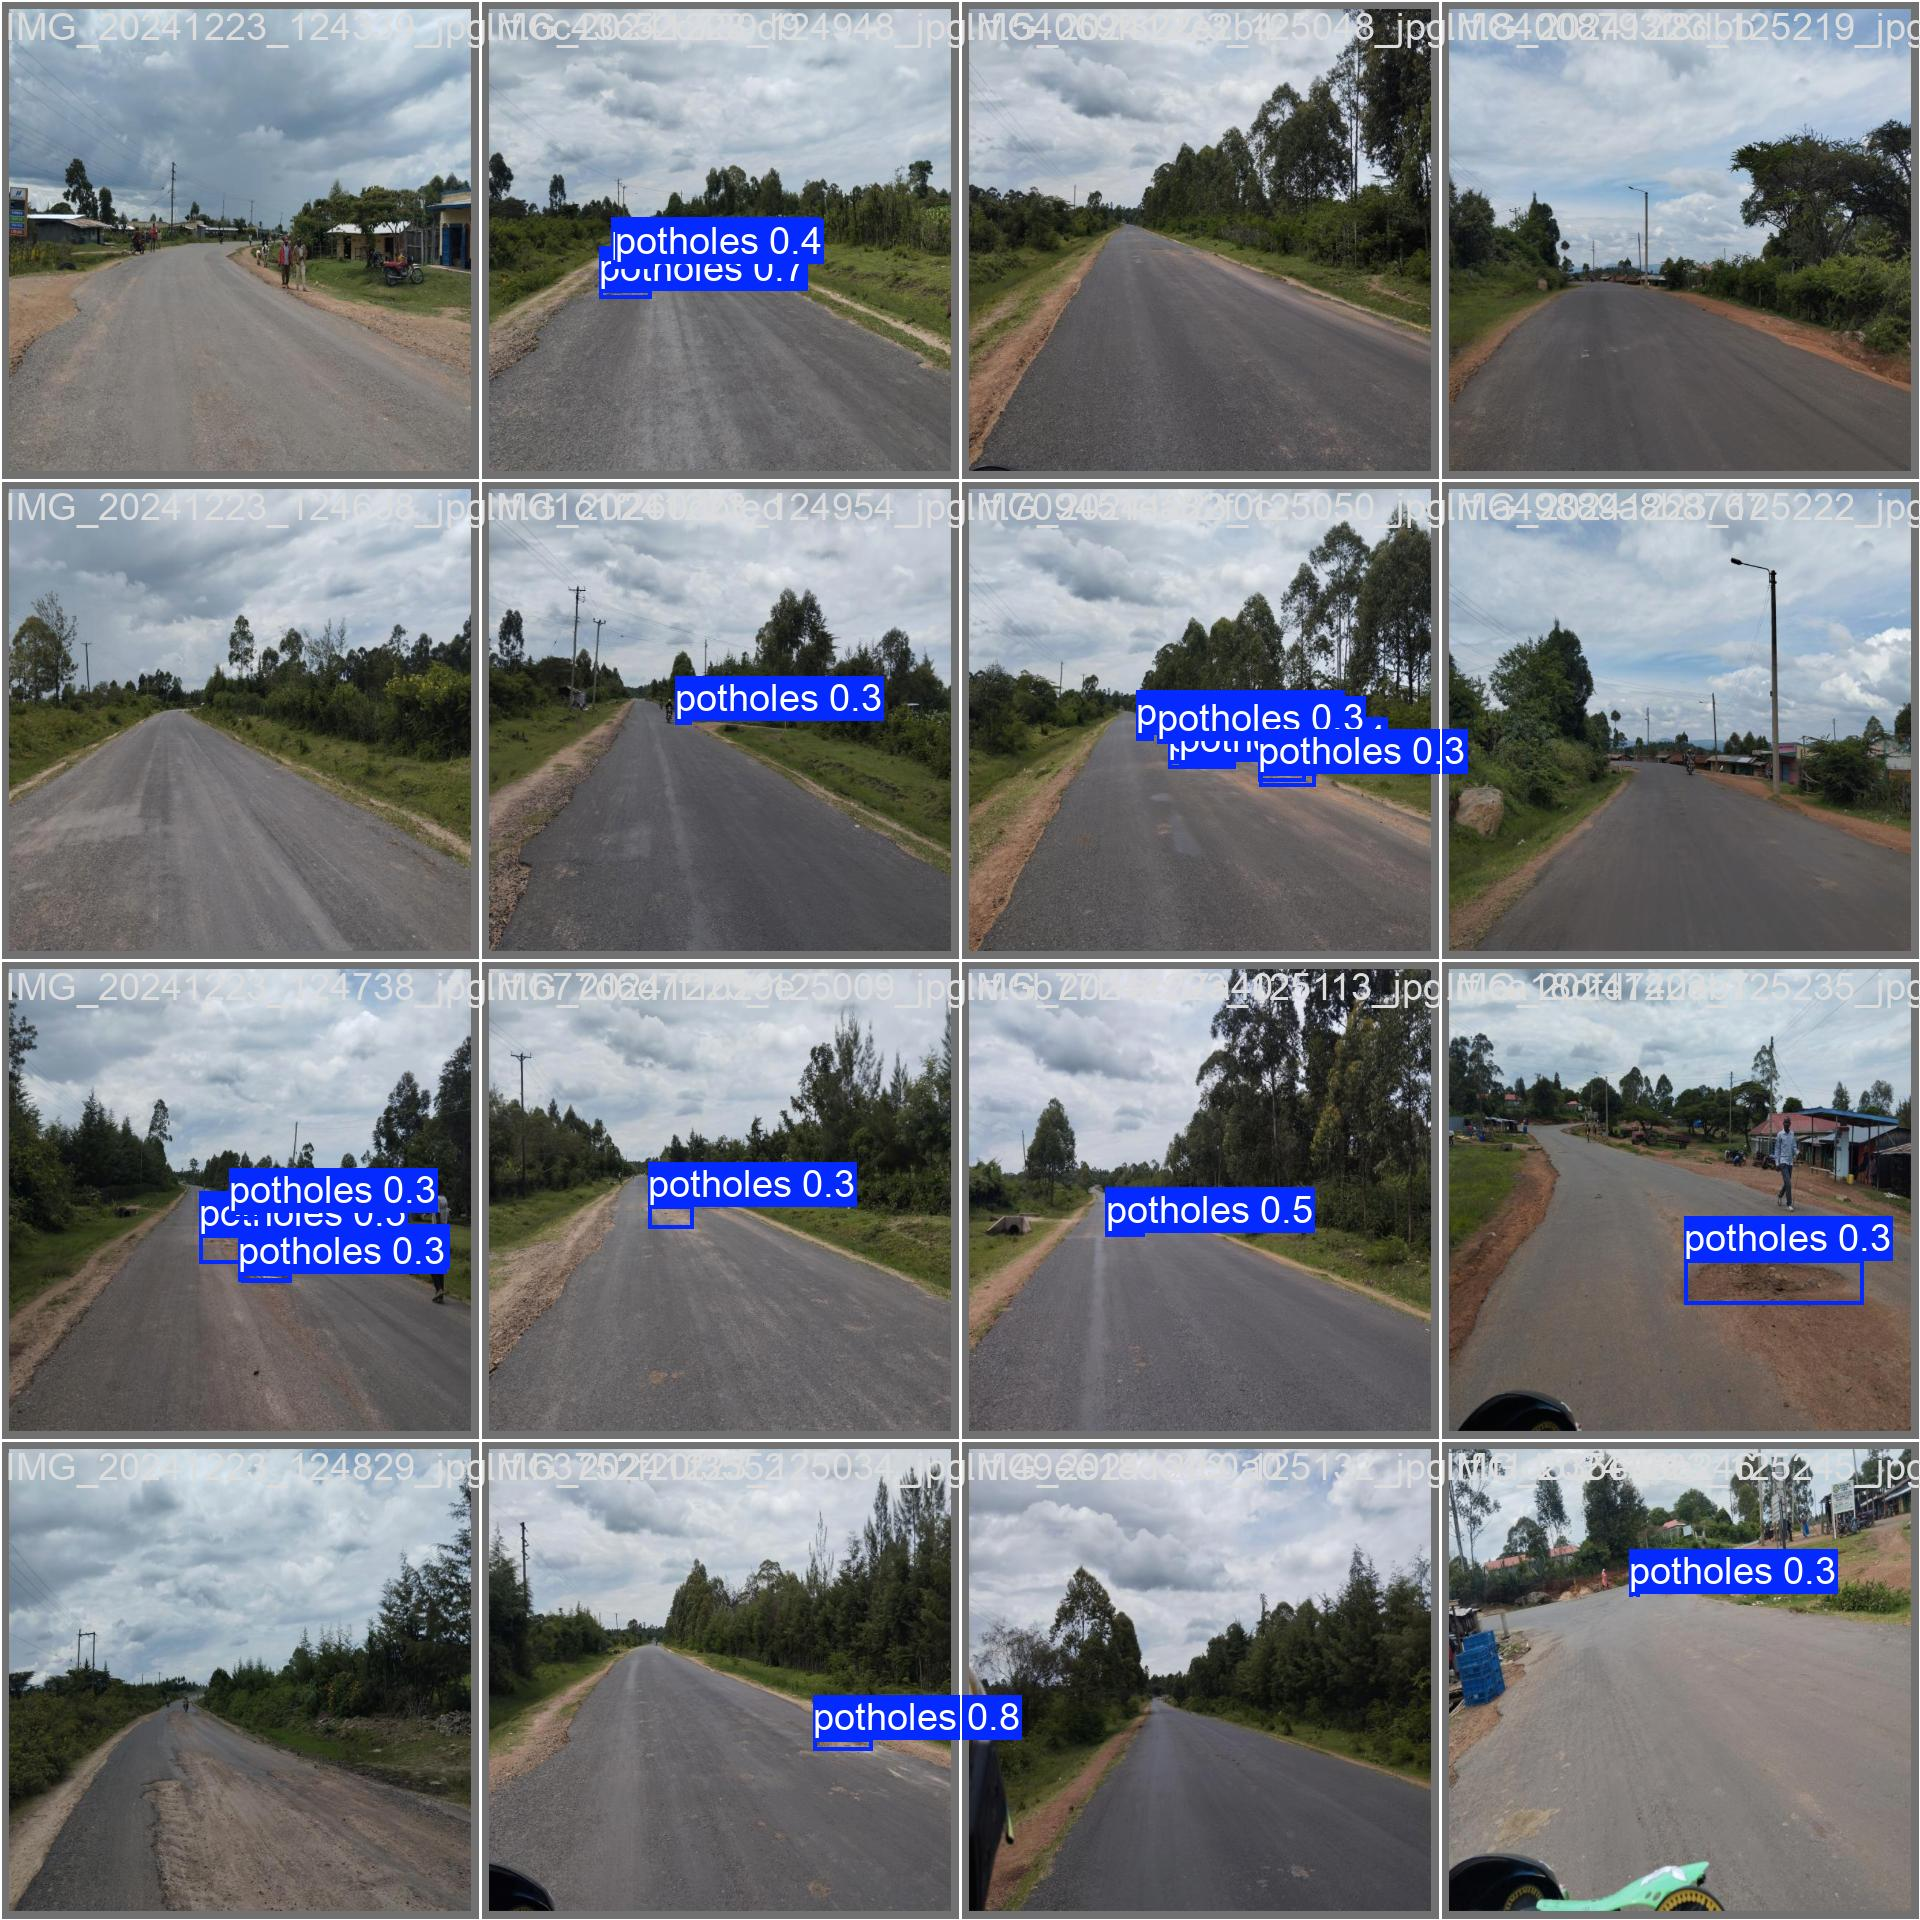

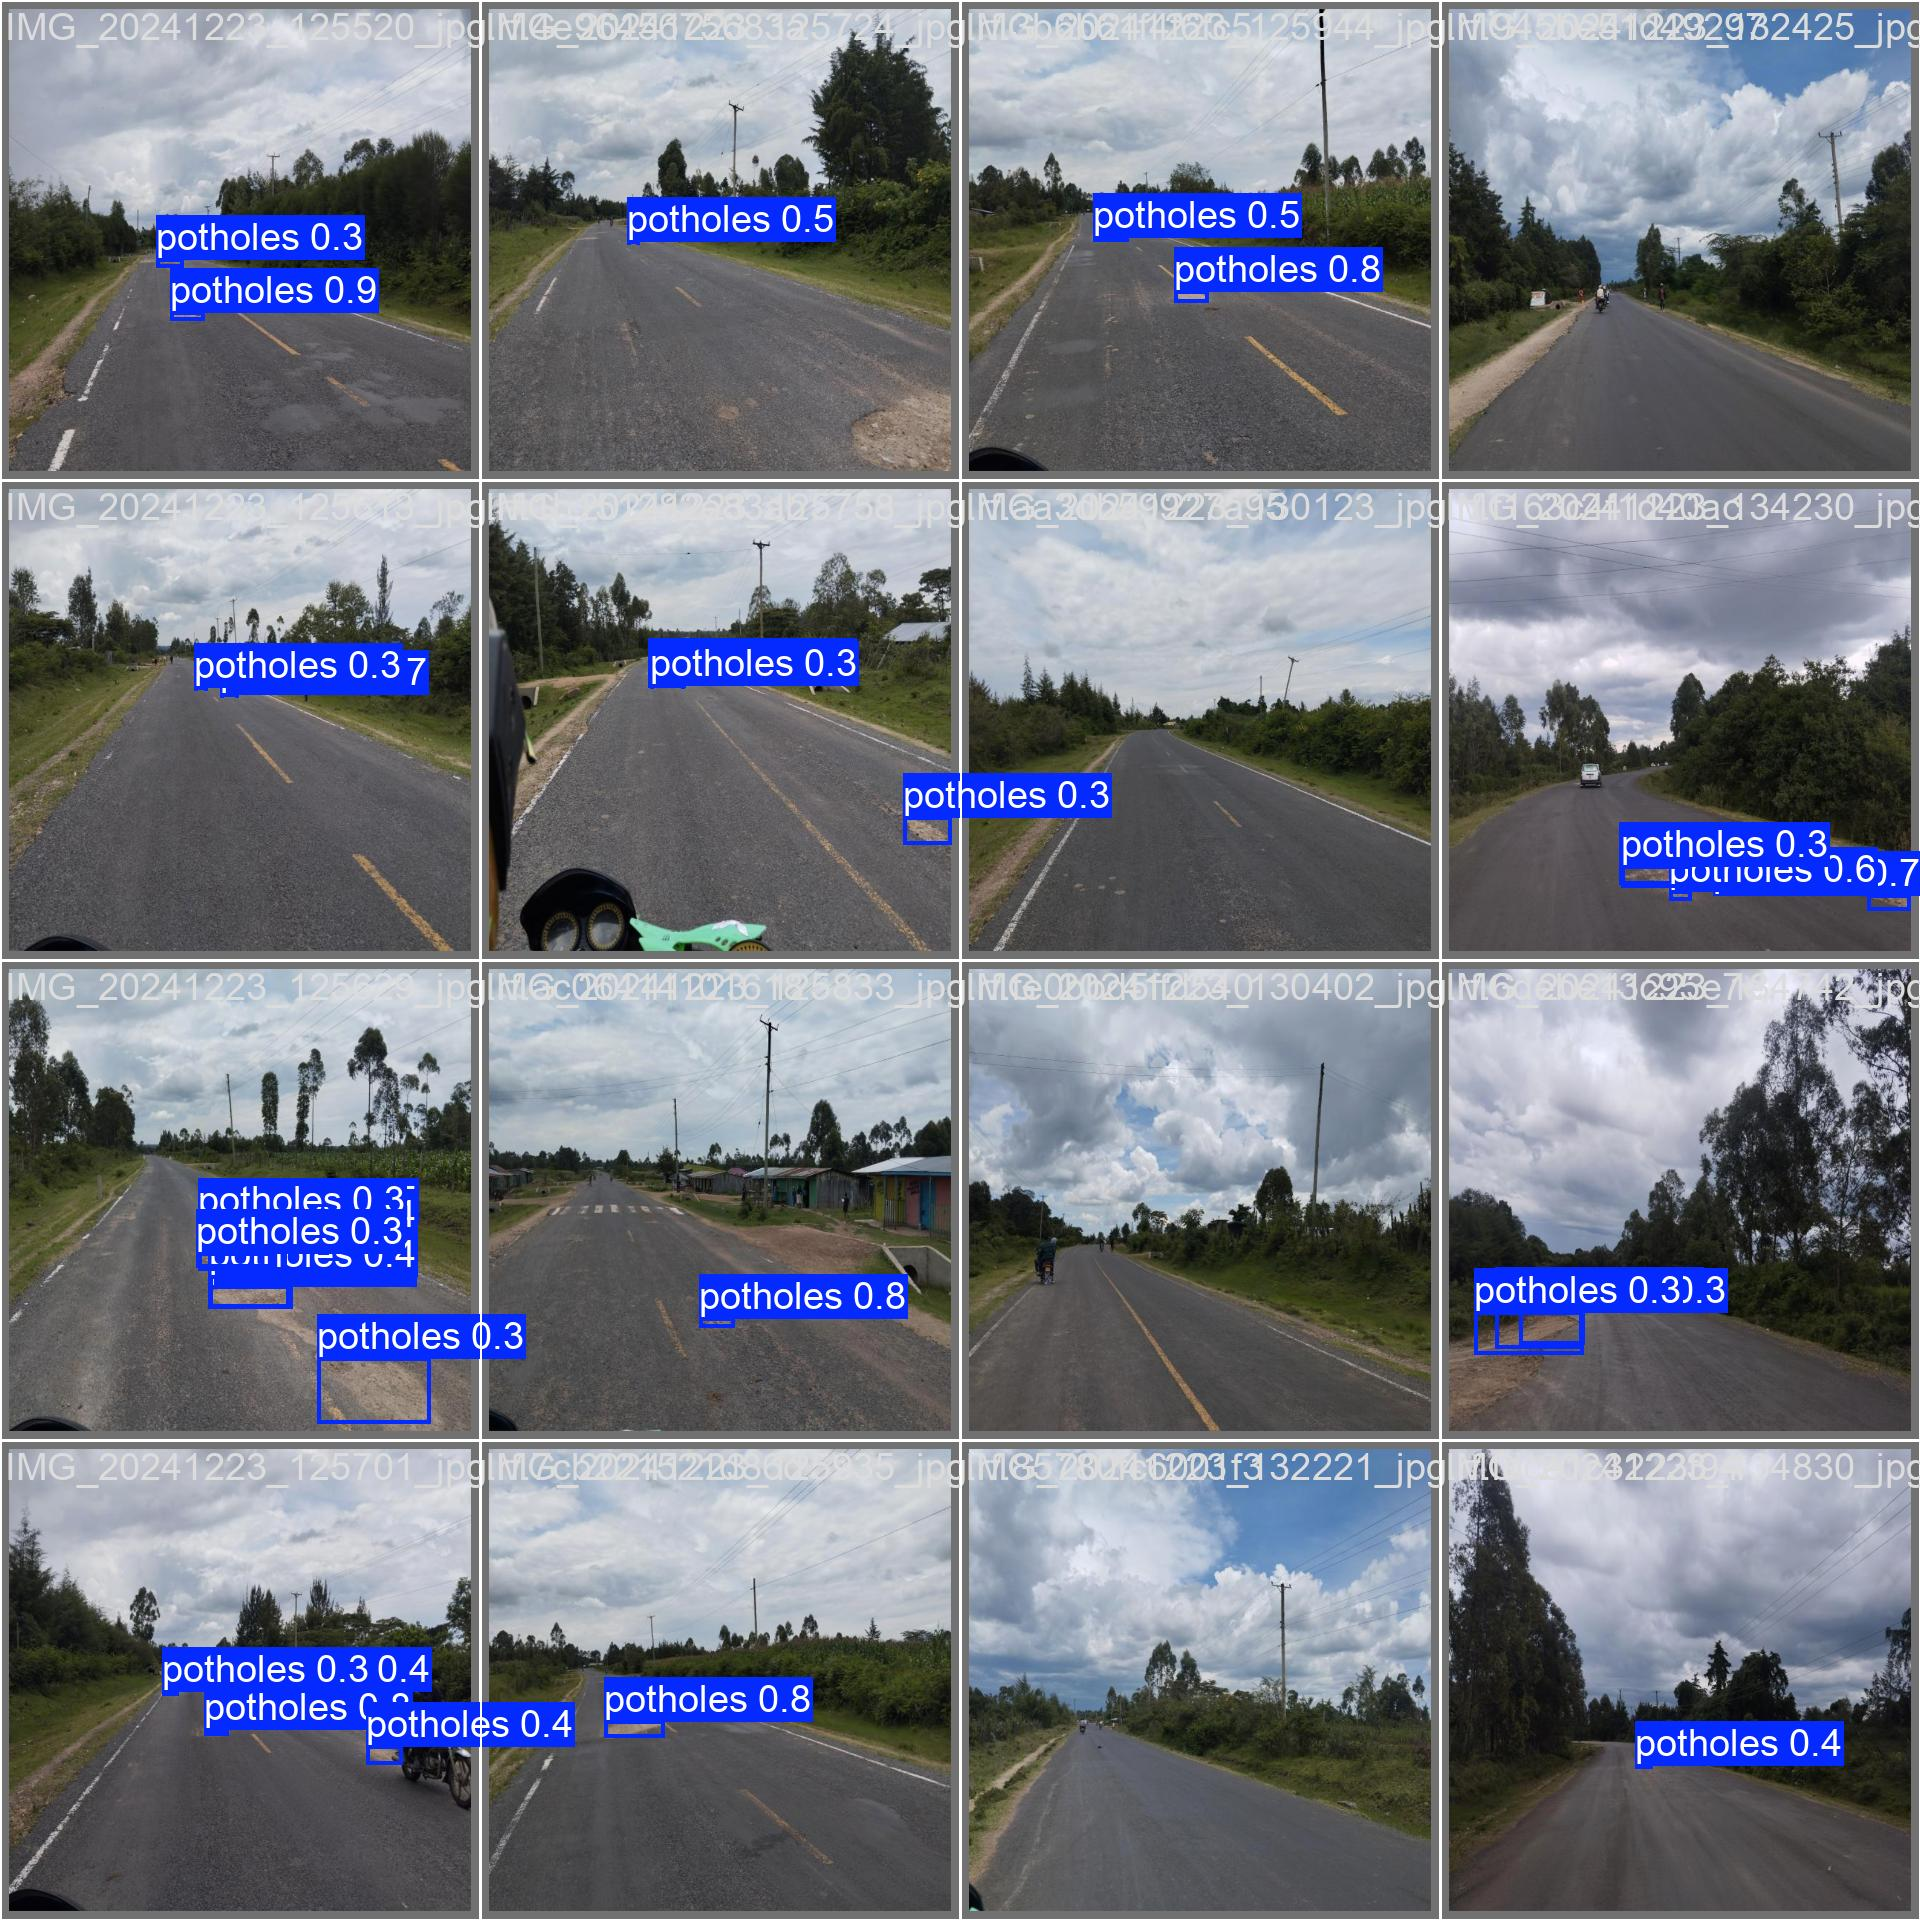

In [14]:
# 3. Display validation predictions
print("--- Validation Predictions ---")
found_images = False

for i in range(10):
    pred_path = f'{results_dir}/val_batch{i}_pred.jpg'
    if os.path.exists(pred_path):
        display(Image(filename=pred_path, width=800))
        found_images = True

if not found_images:
    print("No validation prediction batches (val_batchX_pred.jpg) found.")

2. **Confusion Matrix (`confusion_matrix.png`):** To visualize the ratio of True Positives (correct detections) to False Positives (background mistakenly identified as a pothole).

--- Confusion Matrix ---


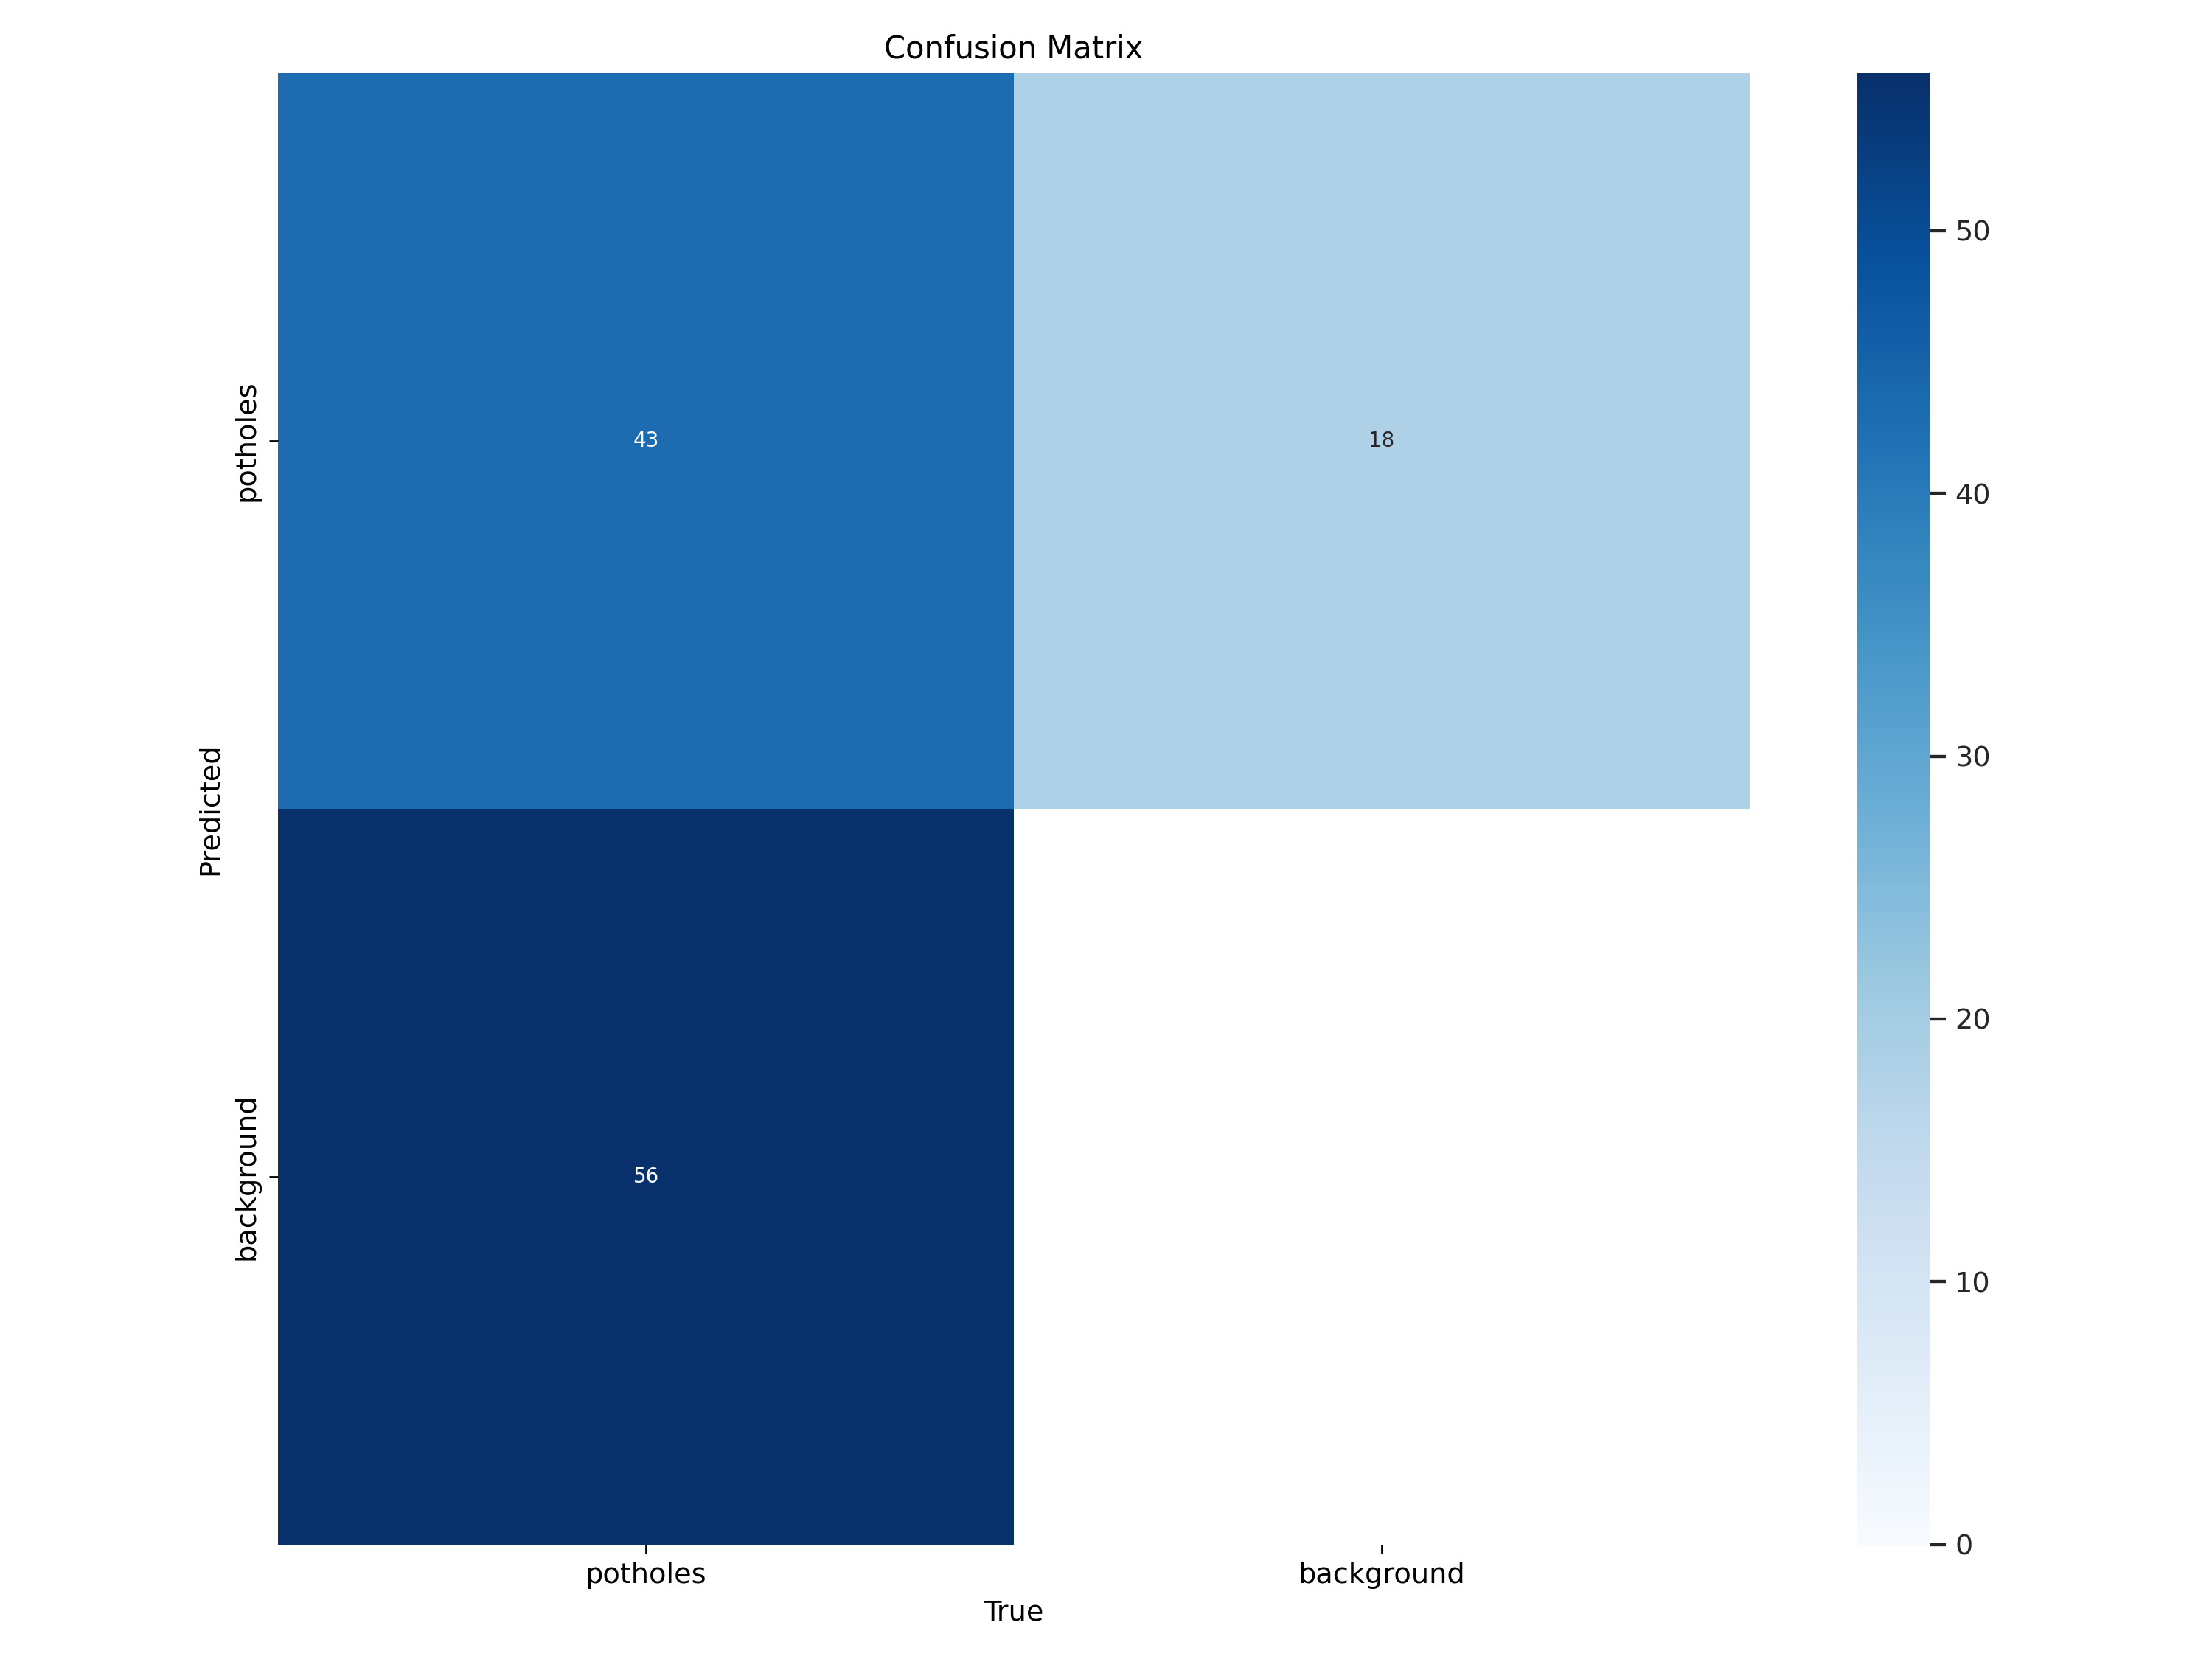

In [15]:
# 2. Display confusion matrix
confusion_matrix = f'{results_dir}/confusion_matrix.png'

if os.path.exists(confusion_matrix):
    print("--- Confusion Matrix ---")
    display(Image(filename=confusion_matrix, width=600))
else:
    print("confusion_matrix.png not found in the specified directory.")

### Data Quality Visualization



---


## 6. Inference on Unseen Data

The ultimate test of an object detection model is its performance on data it has never seen before.

In this final section, we load our newly trained custom weights (`best.pt`) and run inference on the **Test** dataset. We set a confidence threshold of `0.25`, meaning the model will only draw a bounding box if it is at least 25% confident that the detected object is a pothole. Finally, we randomly sample and display the resulting images to visually verify the model's predictive accuracy.

In [18]:


# 1. Load the newly trained custom weights
# (Using the latest_run variable from Section 5 ensures we get the right folder)
best_weights = os.path.join(results_dir, 'weights', 'best.pt')
model = YOLO(best_weights)

# 2. Define the path to the unseen test images using our dynamic variable
test_images_path = f"{dataset.location}/test/images"

# 3. Run inference!
# save=True generates the annotated images
# conf=0.25 sets the confidence threshold
print(f"Running predictions on: {test_images_path}")
results = model.predict(source=test_images_path, save=True, conf=0.25)

# 4. Display a few random predictions
# YOLO saves new predictions in a sequentially numbered 'predict' folder.
# We find the most recent one to ensure we are looking at the latest results.
predict_dirs = glob.glob('runs/detect/predict*')

if predict_dirs:
    latest_predict = max(predict_dirs, key=os.path.getmtime)
    predicted_images = glob.glob(f'{latest_predict}/*.jpg')

    if predicted_images:
        print(f"\n✅ --- Displaying Random Predictions from {latest_predict} ---")
        # Select up to 3 random images
        sample_images = random.sample(predicted_images, min(3, len(predicted_images)))
        for img_path in sample_images:
            display(Image(filename=img_path, width=800))
    else:
        print("No predicted images found inside the prediction folder.")
else:
    print("No prediction directory found. Check if model.predict() succeeded.")

Running predictions on: /content/chepalungu-1/test/images



ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### Analysis Results Visualization

---

## Next Steps: Customizing Your Analysis

### 1. Update Configuration
Edit `fynesse/defaults.yml` to point to your data sources:

### 2. Implement Your Data Access
Modify `fynesse/access.py` to load your specific data:

### 3. Add Data Assessment Logic
Enhance `fynesse/assess.py` with your quality checks:

### 4. Implement Analysis Functions
Customize `fynesse/address.py` for your specific questions: